## 结果比较
要比较的模型：  
### bpe：  
1. 默认参数的模型 fine_tuned_model_D ✅
2. 加载MLM预训练参数的模型 fine_tuned_model_P ✅
### base：  
1. 默认参数的模型 fine_tuned_model_D ✅
2. 加载MLM预训练参数的模型 fine_tuned_model_P ✅
### two_tower: 
1. 默认参数模型 imotifTower_3D8H256D_D ✅
2. 加载MLM预训练参数的模型，但没设置 cross-attention 的参数 imotifTower_3D8H256D_MLM ✅
3. 加载MLM预训练参数的模型，加载并设置全部参数 imotifTower_3D8H256D_MLMA ✅
4. 加载base和bpe精调模型的参数的模型，但没设置 cross-attention 的参数 imotifTower_3D8H256D_P3 ✅
5. 加载base和bpe精调模型的参数的模型，加载并设置全部参数 imotifTower_3D8H256D_P4 ✅
6. 基于编号3模型进一步半监督学习的模型，在之前的数据上额外加 imotifTower_3D8H256D_semi_v1 ✅
7. 基于编号3模型进一步半监督学习的模型，用伪标签正例补充正例，不重复生成正例 imotifTower_3D8H256D_semi_v2 ✅
### retrained_seeker:
Accuracy: 0.7865497076023392
Cross-Entropy Loss: 0.4856150731453027
Cross-Entropy Loss: 0.6006501913070679
AUROC: 0.8819901382254176
AUPRC: 0.879701536392667
Precision: 0.8834714773281326
Recall: 0.6610726012404232
F1-score: 0.7562604340567612

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[0.49608039855956976, 0.2956704914569852, 0.2735074102878566, 0.27061037421226486, 0.26647391915321295, 0.23383305966854043, 0.262760072946548, 0.26103929877281146, 0.2182670235633844, 0.21798451840877503, 0.2153492689132686, 0.18276119530200902]


<Figure size 800x600 with 0 Axes>

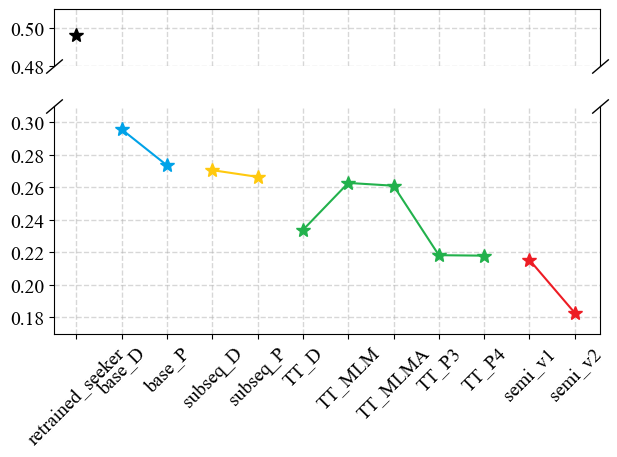

In [27]:
#best_model_eval_metrics.txt format: {'eval_loss': 0.28380945324897766, 'eval_accuracy': 0.9183078045222466, 'eval_auroc': 0.966364321697601, 'eval_auprc': 0.9702966557443437, 'eval_recall': 0.9197665937272064, 'eval_precision': 0.9170909090909091, 'eval_f1': 0.9184268026219956, 'eval_runtime': 0.7548, 'eval_samples_per_second': 7265.103, 'eval_steps_per_second': 14.573, 'epoch': 100.0}
'''
从各个模型目录下的best_model_eval_metrics.txt文件中读取模型评估指标，然后将这些指标画到图中
'''

import sys

sys.path.append("../")
from utils.parameters import *
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
from openpyxl import load_workbook

result_path = os.path.join("..", "train_two_tower_model", "content", "results.xlsx")

# 画 eval_loss
workbook = load_workbook(result_path, data_only=True)
sheet1 = workbook["Sheet1"]
eval_loss = [] # start with retrained_seeker's metrics
for row in range(2,14):
    eval_loss.append(sheet1.cell(row=row, column=10).value)
print(eval_loss)

plt.rcParams.update({'font.size': 14})
plt.rc('font', family='Times New Roman')
plt.figure(figsize=(8, 6))
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=100, gridspec_kw={'height_ratios': [1, 4]})
ax1.plot([0], eval_loss[0], marker="*", markersize=10, color="#000")
ax2.plot([1,2], eval_loss[1:3], marker="*", markersize=10, color="#00A2E8")
ax2.plot([3,4], eval_loss[3:5], marker="*", markersize=10, color="#FFC90E")
ax2.plot([5,6,7,8,9], eval_loss[5:10], marker="*", markersize=10, color="#22B14C")
ax2.plot([10,11], eval_loss[10:12], marker="*", markersize=10, color="#ED1C24")
plt.xticks(range(12), ["retrained_seeker", "base_D", "base_P", "subseq_D", "subseq_P", "TT_D", "TT_MLM", "TT_MLMA", "TT_P3", "TT_P4", "semi_v1", "semi_v2"], rotation=45)
plt.xlim(-0.5)

y_major_locator = MultipleLocator(0.02) # y轴刻度间隔设置
ax1.yaxis.set_major_locator(y_major_locator)
y_major_locator = MultipleLocator(0.02) # y轴刻度间隔设置
ax2.yaxis.set_major_locator(y_major_locator)

ax1.set_ylim(.48, .51)  # 子图1设置y轴范围，只显示部分图
ax2.set_ylim(.17, .31)  # 子图2设置y轴范围，只显示部分图

ax1.spines['bottom'].set_visible(False)#关闭子图1中底部脊
ax2.spines['top'].set_visible(False)##关闭子图2中顶部脊
ax1.tick_params(axis='x',length=0)#子图1x轴刻度线长度设置为0

# 添加网格线
ax1.grid(ls='--',alpha=0.5,linewidth=1)
ax2.grid(ls='--',alpha=0.5,linewidth=1)

d = .85  #设置倾斜度
#绘制断裂处的标记
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle='none', color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0],transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# plt.legend()
plt.tight_layout()
plt.savefig("../figures/performance_comparison/eval_loss.eps", format="eps", bbox_inches="tight")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[0.7943543103504664, 0.9077183440480624, 0.9109648552081191, 0.9039251727888177, 0.9070622614532379, 0.9302965264478052, 0.9116623313770589, 0.9147949086606889, 0.9372998056633055, 0.9333612743888823, 0.9400718510896073, 0.9420416955058271]


<Figure size 800x600 with 0 Axes>

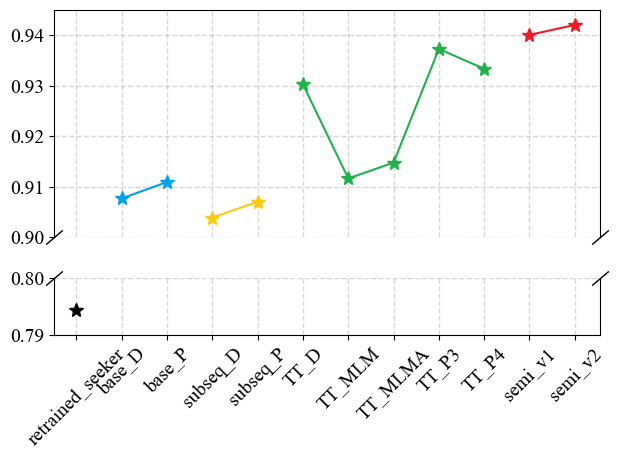

In [28]:
# 画 eval_accuracy
eval_accuracy = [] # start with retrained_seeker's metrics
for row in range(2,14):
    eval_accuracy.append(sheet1.cell(row=row, column=14).value)
print(eval_accuracy)


plt.rc('font', family='Times New Roman')
plt.figure(figsize=(8, 6))
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=100, gridspec_kw={'height_ratios': [4, 1]})
ax2.plot([0], eval_accuracy[0], marker="*", markersize=10, color="#000")
ax1.plot([1,2], eval_accuracy[1:3], marker="*", markersize=10, color="#00A2E8")
ax1.plot([3,4], eval_accuracy[3:5], marker="*", markersize=10, color="#FFC90E")
ax1.plot([5,6,7,8,9], eval_accuracy[5:10], marker="*", markersize=10, color="#22B14C")
ax1.plot([10,11], eval_accuracy[10:12], marker="*", markersize=10, color="#ED1C24")
plt.xticks(range(12), ["retrained_seeker", "base_D", "base_P", "subseq_D", "subseq_P", "TT_D", "TT_MLM", "TT_MLMA", "TT_P3", "TT_P4", "semi_v1", "semi_v2"], rotation=45)
plt.xlim(-0.5)

y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax1.yaxis.set_major_locator(y_major_locator)
y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax2.yaxis.set_major_locator(y_major_locator)

ax1.set_ylim(.90, .945)  # 子图1设置y轴范围，只显示部分图
ax2.set_ylim(.79, .80)  # 子图2设置y轴范围，只显示部分图

ax1.spines['bottom'].set_visible(False)#关闭子图1中底部脊
ax2.spines['top'].set_visible(False)##关闭子图2中顶部脊
ax1.tick_params(axis='x',length=0)#子图1x轴刻度线长度设置为0

# 添加网格线
ax1.grid(ls='--',alpha=0.5,linewidth=1)
ax2.grid(ls='--',alpha=0.5,linewidth=1)

d = .85  #设置倾斜度
#绘制断裂处的标记
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle='none', color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0],transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# plt.legend()
plt.tight_layout()
plt.savefig("../figures/performance_comparison/eval_acc.eps", format="eps", bbox_inches="tight")

In [29]:
# # 画 eval_precision
# eval_precision = [] # start with retrained_seeker's metrics
# for row in range(2,14):
#     eval_precision.append(sheet1.cell(row=row, column=14).value)
# print(eval_precision)

# plt.rc('font', family='Times New Roman')
# plt.figure(figsize=(8, 6))
# plt.plot([0], eval_precision[0], marker="*", markersize=10, color="#000")
# plt.plot([1,2], eval_precision[1:3], marker="*", markersize=10, color="#00A2E8")
# plt.plot([3,4], eval_precision[3:5], marker="*", markersize=10, color="#FFC90E")
# plt.plot([5,6,7,8,9], eval_precision[5:10], marker="*", markersize=10, color="#22B14C")
# plt.plot([10,11], eval_precision[10:12], marker="*", markersize=10, color="#ED1C24")
# plt.xticks(range(12), ["retrained_seeker", "base_D", "base_P", "subseq_D", "subseq_P", "TT_D", "TT_MLM", "TT_MLMA", "TT_P3", "TT_P4", "semi_v1", "semi_v2"], rotation=45, fontsize=16)
# plt.yticks(fontsize=16)
# plt.xlim(-0.5)

# plt.grid(ls='--',alpha=0.5,linewidth=1)

# plt.tight_layout()
# plt.savefig("../figures/performance_comparison/eval_precision.eps", format="eps", bbox_inches="tight")

In [30]:
# # 画 eval_recall
# eval_recall = [0.6610726012404232] # start with retrained_seeker's metrics
# for model_path in model_paths:
#     with open(os.path.join(model_path, "best_model_eval_metrics.txt"), "r") as f:
#         line = f.readline().strip().split(",")
#         eval_recall.append(float(line[4].split(":")[-1]))
# print(eval_recall)

# plt.rc('font', family='Times New Roman')
# plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=100, gridspec_kw={'height_ratios': [4, 1]})
# ax2.plot([0], eval_recall[0], marker="*", markersize=10, color="#000")
# ax1.plot([1,2], eval_recall[1:3], marker="*", markersize=10, color="#00A2E8")
# ax1.plot([3,4], eval_recall[3:5], marker="*", markersize=10, color="#FFC90E")
# ax1.plot([5,6,7,8,9], eval_recall[5:10], marker="*", markersize=10, color="#22B14C")
# ax1.plot([10,11], eval_recall[10:12], marker="*", markersize=10, color="#ED1C24")
# plt.xticks(range(12), ["retrained_seeker", "base_D", "base_P", "subseq_D", "subseq_P", "TT_D", "TT_MLM", "TT_MLMA", "TT_P3", "TT_P4", "semi_v1", "semi_v2"], rotation=45)
# plt.xlim(-0.5)

# y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
# ax1.yaxis.set_major_locator(y_major_locator)
# y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
# ax2.yaxis.set_major_locator(y_major_locator)

# ax1.set_ylim(.88, .94)  # 子图1设置y轴范围，只显示部分图
# ax2.set_ylim(.655, .67)  # 子图2设置y轴范围，只显示部分图

# ax1.spines['bottom'].set_visible(False)#关闭子图1中底部脊
# ax2.spines['top'].set_visible(False)##关闭子图2中顶部脊
# ax1.tick_params(axis='x',length=0)#子图1x轴刻度线长度设置为0

# # 添加网格线
# ax1.grid(ls='--',alpha=0.5,linewidth=1)
# ax2.grid(ls='--',alpha=0.5,linewidth=1)

# d = .85  #设置倾斜度
# #绘制断裂处的标记
# kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
#               linestyle='none', color='k', mec='k', mew=1, clip_on=False)
# ax1.plot([0, 1], [0, 0],transform=ax1.transAxes, **kwargs)
# ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# plt.tight_layout()
# plt.savefig("../figures/performance_comparison/eval_recall.eps", format="eps", bbox_inches="tight")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[0.7701388594463963, 0.9064911565886025, 0.9104420182344134, 0.9041231671939023, 0.9075303418253331, 0.9303016727886781, 0.923701974870658, 0.9148850535603412, 0.9367989764455718, 0.9326334817493658, 0.9397216488607318, 0.9424036130922504]


<Figure size 800x600 with 0 Axes>

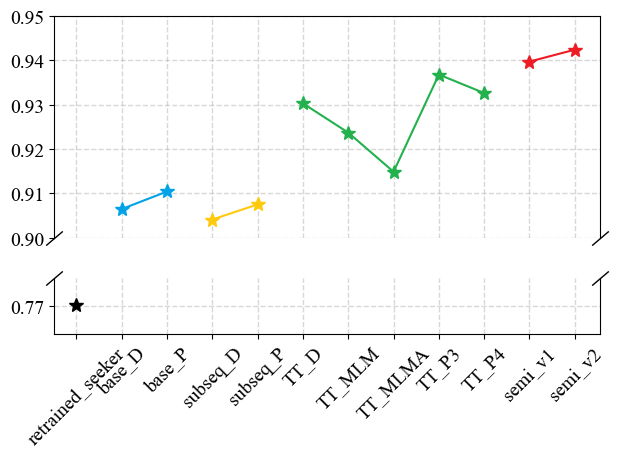

In [31]:
# 画 eval_f1
eval_f1 = [] # start with retrained_seeker's metrics
for row in range(2,14):
    eval_f1.append(sheet1.cell(row=row, column=13).value)
print(eval_f1)


plt.rc('font', family='Times New Roman')
plt.figure(figsize=(8, 6))
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=100, gridspec_kw={'height_ratios': [4, 1]})
ax2.plot([0], eval_f1[0], marker="*", markersize=10, color="#000")
ax1.plot([1,2], eval_f1[1:3], marker="*", markersize=10, color="#00A2E8")
ax1.plot([3,4], eval_f1[3:5], marker="*", markersize=10, color="#FFC90E")
ax1.plot([5,6,7,8,9], eval_f1[5:10], marker="*", markersize=10, color="#22B14C")
ax1.plot([10,11], eval_f1[10:12], marker="*", markersize=10, color="#ED1C24")
plt.xticks(range(12), ["retrained_seeker", "base_D", "base_P", "subseq_D", "subseq_P", "TT_D", "TT_MLM", "TT_MLMA", "TT_P3", "TT_P4", "semi_v1", "semi_v2"], rotation=45)
plt.xlim(-0.5)

y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax1.yaxis.set_major_locator(y_major_locator)
y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax2.yaxis.set_major_locator(y_major_locator)

ax1.set_ylim(.90, .95)  # 子图1设置y轴范围，只显示部分图
ax2.set_ylim(.765, .775)  # 子图2设置y轴范围，只显示部分图

ax1.spines['bottom'].set_visible(False)#关闭子图1中底部脊
ax2.spines['top'].set_visible(False)##关闭子图2中顶部脊
ax1.tick_params(axis='x',length=0)#子图1x轴刻度线长度设置为0

# 添加网格线
ax1.grid(ls='--',alpha=0.5,linewidth=1)
ax2.grid(ls='--',alpha=0.5,linewidth=1)

d = .85  #设置倾斜度
#绘制断裂处的标记
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle='none', color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0],transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# plt.legend()
plt.tight_layout()
plt.savefig("../figures/performance_comparison/eval_f1.eps", format="eps", bbox_inches="tight")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[0.8860879416042213, 0.9602594795964853, 0.9665095073420069, 0.9602648471535977, 0.9644372144591188, 0.9753786672502021, 0.9568025968267406, 0.9691582607285646, 0.9809838101831909, 0.9801225791387754, 0.9822402464274596, 0.9838309760315678]


<Figure size 800x600 with 0 Axes>

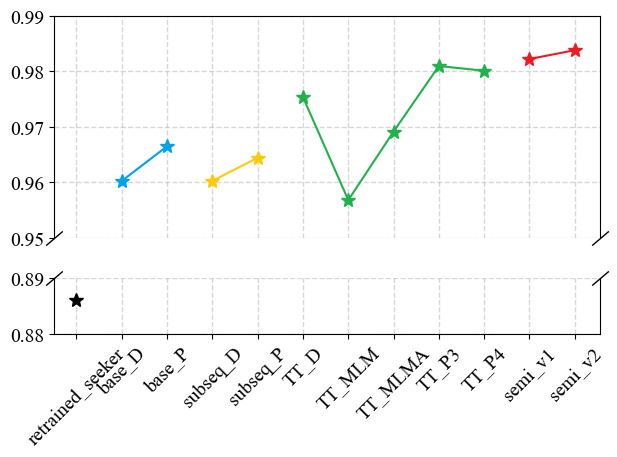

In [32]:
# 画 eval_auroc
eval_auroc = [] # start with retrained_seeker's metrics
for row in range(2,14):
    eval_auroc.append(sheet1.cell(row=row, column=11).value)
print(eval_auroc)


plt.rc('font', family='Times New Roman')
plt.figure(figsize=(8, 6))
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=100, gridspec_kw={'height_ratios': [4, 1]})
ax2.plot([0], eval_auroc[0], marker="*", markersize=10, color="#000")
ax1.plot([1,2], eval_auroc[1:3], marker="*", markersize=10, color="#00A2E8")
ax1.plot([3,4], eval_auroc[3:5], marker="*", markersize=10, color="#FFC90E")
ax1.plot([5,6,7,8,9], eval_auroc[5:10], marker="*", markersize=10, color="#22B14C")
ax1.plot([10,11], eval_auroc[10:12], marker="*", markersize=10, color="#ED1C24")
plt.xticks(range(12), ["retrained_seeker", "base_D", "base_P", "subseq_D", "subseq_P", "TT_D", "TT_MLM", "TT_MLMA", "TT_P3", "TT_P4", "semi_v1", "semi_v2"], rotation=45)
plt.xlim(-0.5)

y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax1.yaxis.set_major_locator(y_major_locator)
y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax2.yaxis.set_major_locator(y_major_locator)

ax1.set_ylim(.95, .99)  # 子图1设置y轴范围，只显示部分图
ax2.set_ylim(.88, .89)  # 子图2设置y轴范围，只显示部分图

ax1.spines['bottom'].set_visible(False)#关闭子图1中底部脊
ax2.spines['top'].set_visible(False)##关闭子图2中顶部脊
ax1.tick_params(axis='x',length=0)#子图1x轴刻度线长度设置为0

# 添加网格线
ax1.grid(ls='--',alpha=0.5,linewidth=1)
ax2.grid(ls='--',alpha=0.5,linewidth=1)

d = .85  #设置倾斜度
#绘制断裂处的标记
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle='none', color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0],transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# plt.legend()
plt.tight_layout()
plt.savefig("../figures/performance_comparison/eval_auroc.eps", format="eps", bbox_inches="tight")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[0.8819782107291145, 0.9631389016810485, 0.9686342751542171, 0.9621043553874875, 0.9667542838698306, 0.9779448690444023, 0.9701903039656532, 0.9714252296207725, 0.9831243184853985, 0.9820083330475201, 0.9841813909121033, 0.9847460004734995]


<Figure size 800x600 with 0 Axes>

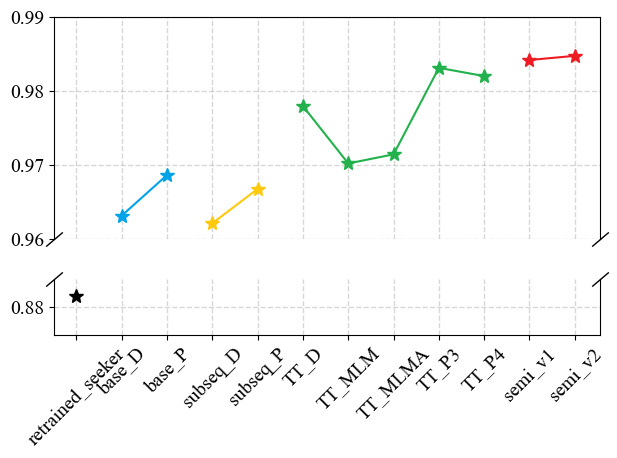

In [33]:
# 画 eval_auprc
eval_auprc = [] # start with retrained_seeker's metrics
for row in range(2,14):
    eval_auprc.append(sheet1.cell(row=row, column=12).value)
print(eval_auprc)


plt.rc('font', family='Times New Roman')
plt.figure(figsize=(8, 6))
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=100, gridspec_kw={'height_ratios': [4, 1]})
ax2.plot([0], eval_auprc[0], marker="*", markersize=10, color="#000")
ax1.plot([1,2], eval_auprc[1:3], marker="*", markersize=10, color="#00A2E8")
ax1.plot([3,4], eval_auprc[3:5], marker="*", markersize=10, color="#FFC90E")
ax1.plot([5,6,7,8,9], eval_auprc[5:10], marker="*", markersize=10, color="#22B14C")
ax1.plot([10,11], eval_auprc[10:12], marker="*", markersize=10, color="#ED1C24")
plt.xticks(range(12), ["retrained_seeker", "base_D", "base_P", "subseq_D", "subseq_P", "TT_D", "TT_MLM", "TT_MLMA", "TT_P3", "TT_P4", "semi_v1", "semi_v2"], rotation=45)
plt.xlim(-0.5)

y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax1.yaxis.set_major_locator(y_major_locator)
y_major_locator = MultipleLocator(0.01) # y轴刻度间隔设置
ax2.yaxis.set_major_locator(y_major_locator)

ax1.set_ylim(.96, .99)  # 子图1设置y轴范围，只显示部分图
ax2.set_ylim(.875, .885)  # 子图2设置y轴范围，只显示部分图

ax1.spines['bottom'].set_visible(False)#关闭子图1中底部脊
ax2.spines['top'].set_visible(False)##关闭子图2中顶部脊
ax1.tick_params(axis='x',length=0)#子图1x轴刻度线长度设置为0

# 添加网格线
ax1.grid(ls='--',alpha=0.5,linewidth=1)
ax2.grid(ls='--',alpha=0.5,linewidth=1)

d = .85  #设置倾斜度
#绘制断裂处的标记
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle='none', color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0],transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# plt.legend()
plt.tight_layout()
plt.savefig("../figures/performance_comparison/eval_auprc.eps", format="eps", bbox_inches="tight")